In [1]:
pip install deepxde

In [12]:
import numpy as np
import deepxde as dde
import matplotlib.pyplot as plt

Ballistic Trajectory Estimation (PINN)



In [3]:
def ballistic_physics(t,y): # y'' + k_m * y' + g = 0 -> a = -g + (k/m)v (vertical ballistic motion)
  g = 9.81
  k_m = 0.1 # drag coefficient / mass
  v = dde.grad.jacobian(y,t)
  a = dde.grad.hessian(y,t)
  return a + k_m * v + g

def ground_truth(t):
  # solve analytic solution:
  g = 9.81
  v0 = 10
  k_m = 0.1
  # y(t) = (v0 + g/k_m) / k_m * (1 - exp(-k_m *t)) - g*t/k_m
  return (v0 + g / k_m) / k_m * (1 - np.exp(-k_m * t)) - g * t / k_m

In [4]:
# set initial conditions and early observations:

t_obs = np.array([[0.0], [0.01], [0.02]])
y_obs = ground_truth(t_obs)

observe_y = dde.icbc.PointSetBC(t_obs, y_obs, component=0)


geom = dde.geometry.TimeDomain(0,3)
ic = dde.icbc.IC(geom, lambda x: 0, lambda x, on_initial: on_initial) #y(0) = 0



In [5]:
# data:
data = dde.data.PDE(geom, ballistic_physics, [ic, observe_y], num_domain=1000, num_boundary=2, solution=ground_truth, num_test=500)

In [6]:
# model and analysis
net = dde.nn.FNN([1] + [64] * 4 + [1], 'tanh', 'Glorot uniform')

model = dde.Model(data, net)
# [PDE, IC_position, IC_vel]

model.compile('adam', lr=0.001, metrics=['l2 relative error'], loss_weights=[1,100,100]) # start with adam, then get to refinement with L-BFGS
model.train(iterations=20000)


model.compile('L-BFGS', metrics=['l2 relative error'], loss_weights=[1,100,100])

losshistory, train_state = model.train()

Compiling model...
'compile' took 0.012120 s

Training model...



Cause: could not parse the source code of <function <lambda> at 0x7b959ee2f740>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x7b959ee2f740>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Step      Train loss                        Test loss                         Test metric   
0         [9.72e+01, 0.00e+00, 1.74e+00]    [9.72e+01, 0.00e+00, 1.74e+00]    [9.77e-01]    
1000      [8.96e+00, 8.31e-01, 2.08e+00]    [8.93e+00, 8.31e-01, 2.08e+00]    [5.15e+00]    
2000      [6.70e-01, 7.80e-01, 3.66e+00]    [6.58e-01, 7.80e-01, 3.66e+00]    [6.01e+00]    
3000      [9.00e-02, 2.55e-01, 9.53e-01]    [8.53e-02, 2.55e-01, 9.53e-01]    [3.12e+00]    
4000      [6.52e-03, 8.72e-04, 3.25e-03]    [5.15e-

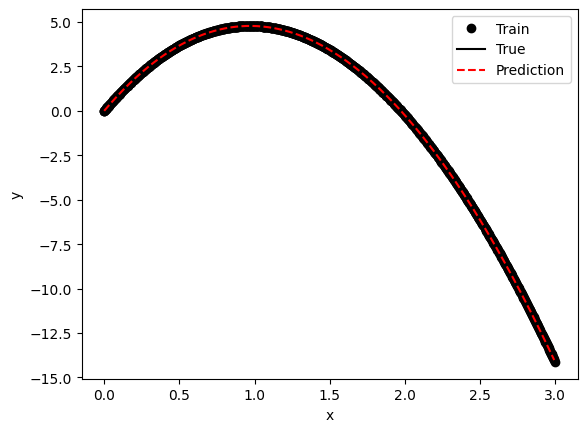

In [7]:
dde.utils.plot_best_state(train_state)

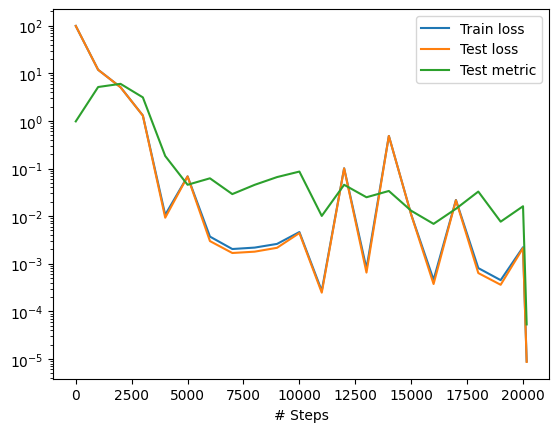

In [8]:
dde.utils.plot_loss_history(losshistory)

Now running the model on 5 different drag coefficient values, and comparing their accuracy.

In [11]:
k_m_vals = [0.01, 0.05, 0.1, 0.5, 1.0]
final_errors = []

for k_m in k_m_vals:
  def ballistic_physics(t,y):
    g = 9.81
    v = dde.grad.jacobian(y, t)
    a = dde.grad.hessian(y,t)
    return a + k_m * v + g

  def ground_truth(t):
    g = 9.81
    v0 =10
    return (v0 + g / k_m) / k_m * (1 - np.exp(-k_m * t)) - g * t / k_m

  t_obs = np.array([[0.0],[0.01], [0.02]])
  y_obs = ground_truth(t_obs)

  observe_y_km = dde.icbc.PointSetBC(t_obs, y_obs)
  ic_km = dde.icbc.IC(geom, lambda x: 0, lambda x, on_initial: on_initial)

  data_km = dde.data.PDE(geom, ballistic_physics, [ic_km, observe_y_km], num_domain=1000, num_boundary=2, solution=ground_truth, num_test=500)

  net_km = dde.nn.FNN([1] + [64] * 4 + [1], 'tanh', 'Glorot uniform')

  model_km = dde.Model(data_km, net_km)
  model_km.compile('adam', lr=0.001, metrics=['l2 relative error'], loss_weights=[1,100,100])
  model_km.train(iterations=20000)
  model_km.compile("L-BFGS", metrics=['l2 relative error'], loss_weights=[1,100,100])
  losshistory_km, train_state_km = model_km.train()

  final_errors.append(train_state_km.best_metrics[0])
  print(f"Final Error for k_m = {k_m}: {train_state_km.best_metrics[0]}")


Compiling model...
'compile' took 0.003928 s

Training model...



Cause: could not parse the source code of <function <lambda> at 0x7b957ee9cfe0>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x7b957ee9cfe0>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Step      Train loss                        Test loss                         Test metric   
0         [9.76e+01, 0.00e+00, 1.74e+00]    [9.76e+01, 0.00e+00, 1.74e+00]    [9.82e-01]    
1000      [5.56e+00, 4.20e-01, 2.06e+00]    [5.53e+00, 4.20e-01, 2.06e+00]    [5.16e+00]    
2000      [2.65e-01, 7.04e-01, 2.60e+00]    [2.60e-01, 7.04e-01, 2.60e+00]    [5.67e+00]    
3000      [1.41e-01, 4.79e-01, 1.77e+00]    [1.38e-01, 4.79e-01, 1.77e+00]    [4.67e+00]    
4000      [6.71e-03, 8.23e-03, 3.06e-02]    [5.23e-

Cause: could not parse the source code of <function <lambda> at 0x7b959c2e8ae0>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x7b959c2e8ae0>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Step      Train loss                        Test loss                         Test metric   
0         [9.74e+01, 0.00e+00, 1.74e+00]    [9.74e+01, 0.00e+00, 1.74e+00]    [9.80e-01]    
1000      [6.52e+00, 6.08e-01, 2.11e+00]    [6.49e+00, 6.08e-01, 2.11e+00]    [5.22e+00]    
2000      [1.36e+00, 1.23e+01, 5.17e+00]    [1.34e+00, 1.23e+01, 5.17e+00]    [5.78e+00]    
3000      [2.13e-01, 6.49e-01, 2.40e+00]    [2.08e-01, 6.49e-01, 2.40e+00]    [5.22e+00]    
4000      [4.43e-02, 1.64e-01, 8.69e-02]    [4.17e-

...

Cause: could not parse the source code of <function <lambda> at 0x7b957ea234c0>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Step      Train loss                        Test loss                         Test metric   
0         [9.72e+01, 0.00e+00, 1.74e+00]    [9.72e+01, 0.00e+00, 1.74e+00]    [9.77e-01]    
1000      [8.96e+00, 8.31e-01, 2.08e+00]    [8.93e+00, 8.31e-01, 2.08e+00]    [5.15e+00]    
2000      [6.70e-01, 7.80e-01, 3.66e+00]    [6.58e-01, 7.80e-01, 3.66e+00]    [6.01e+00]    
3000      [9.00e-02, 2.55e-01, 9.53e-01]    [8.53e-02, 2.55e-01, 9.53e-01]    [3.12e+00]    
4000      [6.52e-03, 8.72e-04, 3.25e-03]    [5.15e-

Cause: could not parse the source code of <function <lambda> at 0x7b957e463d80>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x7b957e463d80>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Step      Train loss                        Test loss                         Test metric   
0         [9.55e+01, 0.00e+00, 1.73e+00]    [9.55e+01, 0.00e+00, 1.73e+00]    [9.60e-01]    
1000      [4.25e-02, 2.31e-02, 8.91e-02]    [3.79e-02, 2.31e-02, 8.91e-02]    [6.89e-01]    
2000      [1.01e-02, 5.27e-03, 1.97e-02]    [8.99e-03, 5.27e-03, 1.97e-02]    [3.25e-01]    
3000      [3.18e-03, 9.99e-04, 5.34e-03]    [2.74e-03, 9.99e-04, 5.34e-03]    [1.63e-01]    
4000      [3.17e-03, 1.85e-03, 7.71e-03]    [2.69e-

Cause: could not parse the source code of <function <lambda> at 0x7b957e01ad40>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x7b957e01ad40>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Step      Train loss                        Test loss                         Test metric   
0         [9.34e+01, 0.00e+00, 1.71e+00]    [9.34e+01, 0.00e+00, 1.71e+00]    [9.44e-01]    
1000      [6.82e-03, 1.87e-04, 7.38e-04]    [6.09e-03, 1.87e-04, 7.38e-04]    [4.92e-02]    
2000      [7.16e-03, 3.48e-04, 7.75e-04]    [6.59e-03, 3.48e-04, 7.75e-04]    [5.39e-02]    
3000      [5.04e-03, 7.46e-05, 2.86e-04]    [4.57e-03, 7.46e-05, 2.86e-04]    [3.08e-02]    
4000      [4.62e-03, 1.37e-04, 5.01e-04]    [4.19e-

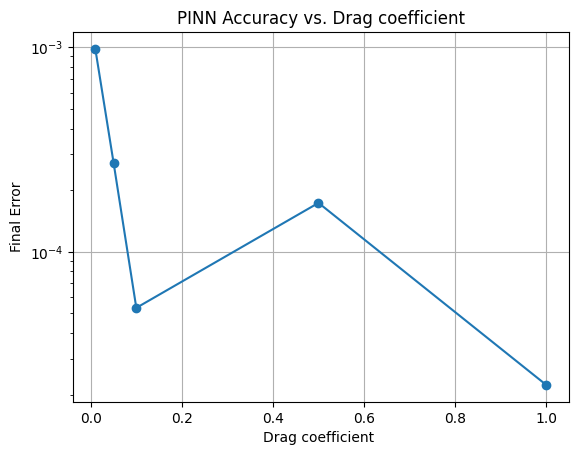

<Figure size 640x480 with 0 Axes>

In [15]:
plt.plot(k_m_vals, final_errors, marker='o')
plt.xlabel('Drag coefficient ')
plt.ylabel('Final Error')
plt.yscale('log')
plt.title('PINN Accuracy vs. Drag coefficient')
plt.grid(True)
plt.show()
# plt.savefig("km_vs_error.png", dpi=150)